In [1]:
import numpy as np
import matplotlib.pyplot as plt
import transport.dispersion as dispersion
import transport.orbitcreation as orbitcreation
import transport.conductivity as conductivity
from transport.makesigmalist import makelist_parallel,makelist_serial
from time import time

repository_directory = "C:/Users/Sahas/OneDrive/Documents/PhD data/Modelling/Python code/boltzmann_transport_git/boltzmann_transport/"
#repository_directory = "C:/Users/kamat/OneDrive/Documents/PhD data/Modelling/Python code/boltzmann_transport_git/boltzmann_transport/"

In [2]:

class FitTrajectory:
    def __init__(self):
        self.data = {}

    def add(self, paramsdict):
        for key, value in paramsdict.items():
            if key not in self.data:
                self.data[key] = []
            if isinstance(value, np.ndarray):
                self.data[key].append(value.copy())
            else:
                self.data[key].append(value)

    def save(self, filename):
        np.savez_compressed(
            filename,
            **{k: np.asarray(v) for k, v in self.data.items()}
        )

trajectory = FitTrajectory()

<>:76: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:77: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:87: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:88: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:92: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:76: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:77: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences wil

Time taken to create Fermi Surface = 0.05850553512573242
Doping = 0.23823958569583503%
Time taken to create B independent Amatrix =  0.43957948684692383
Theta=0. Calculated total area: 4.238851943607889. Number of orbits used 20. Size of Amatrix: 2000
Theta=0. Calculated total area: 4.238851943607889. Number of orbits used 20. Size of Amatrix: 2000
rho_xx = 19.835832560779153, rho_xy (9 T) = 0.4685479807086777
execution time: 1.6195950508117676
Doping=0.23823958569583503


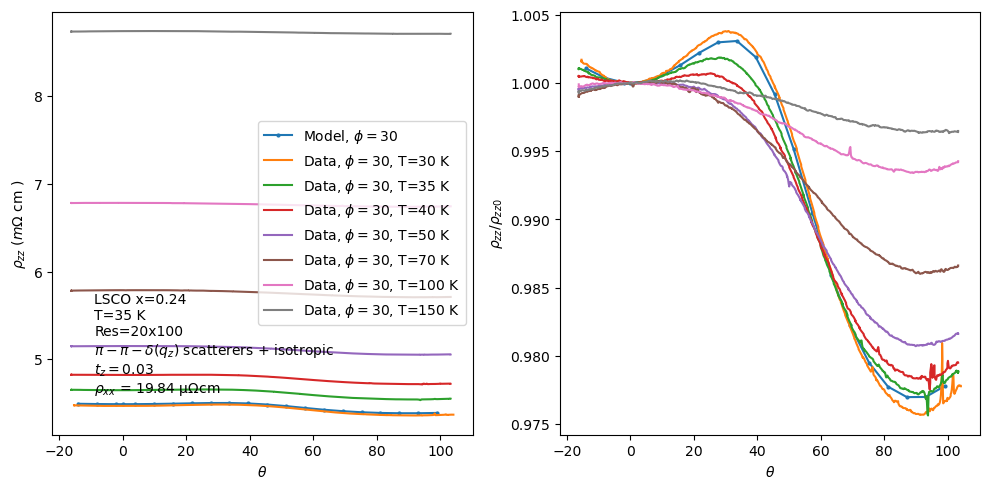

In [8]:
theta_min,theta_max,n_thetas = -14,99,20

starttime_global = time()
thetalist = np.sort(np.concatenate([np.linspace(theta_min,theta_max,n_thetas),[0]])) #list of 20 numbers from -14 to 99 but 0 is forced in there

res_z = 20
res_xy = 100
scatteringmodel="pipidelta_exp"
Tzmultvalue,invtau_iso,strength,spread_xy,n = 0.03335831504060885,9.049302623809513,17.910520030952803,0.123,4
mumultvalue=0.81
T,T1multvalue,T11multvalue = 190e-3,-0.132,0.066

plotScattering=False

dispersionInstance = dispersion.LSCOdispersion(T= T,T1multvalue=T1multvalue,T11multvalue=T11multvalue,Tzmultvalue=Tzmultvalue,mumultvalue=mumultvalue)
FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
starttime = time()
alpha = 0.1
FSorbitsInstance.createFS(tilingformat="variable",alpha=alpha,parallelised=False)
endtime = time() 
print(f"Time taken to create Fermi Surface = {endtime - starttime}")
doping = FSorbitsInstance.calculateDoping()

def create_rhozz(phi,Bmag,plotScattering=plotScattering):
    phi_rad = np.deg2rad(phi)
    conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=invtau_iso,delta_in_k=True)
    starttime = time()
    conductivityInstance.createAmatrix_Bindependent_isotropic()

    conductivityInstance.create_Hfunc(scatteringmodel=scatteringmodel,strength=strength,spread_xy=spread_xy,n=n)
    conductivityInstance.createAmatrix_Bindependent_fwdscatter_out()
    conductivityInstance.createAmatrix_Bindependent_fwdscatter_in()

    if plotScattering: conductivityInstance.plotScatteringOut()
    endtime = time()
    print(f"Time taken to create B independent Amatrix =  {endtime - starttime}")

    def getsigma(theta,Bmag=Bmag):
        B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]
        conductivityInstance.createAmatrix_Bdependent(B)
        conductivityInstance.createAlpha()
        conductivityInstance.createSigma()

        print(f"Theta={theta}. Calculated total area: {conductivityInstance.areasum}. Number of orbits used {len(conductivityInstance.FSorbitsInstance.FSorbits)}. Size of Amatrix: {conductivityInstance.n}")
        return conductivityInstance.sigma,conductivityInstance.areasum


    sigmalist,rholist,arealist = makelist_parallel(getsigma,thetalist,workers=5)
    sigma_zero,area_zero = getsigma(theta=0,Bmag=0)
    sigma_9T,area_9T = getsigma(theta=0,Bmag=9)

    rho_zero = np.linalg.inv(sigma_zero)
    rho_9T = np.linalg.inv(sigma_9T)

    rhozzlist= [rho[2,2]*10e-5 for rho in rholist]
    print(f"rho_xx = {rho_zero[0,0]*10e-2}, rho_xy (9 T) = {rho_9T[0,1]*10e-2}")
    

    endtime_global = time()
    print(f"execution time: {endtime_global-starttime_global}")

    return rhozzlist,rho_zero,rho_9T

#p.savetxt("rhoxyvstPhi"+str(phi)+".dat",np.transpose([thetalist,rhoxylist]))

#generate data
rhozzlist30,rho_zero,rho_9T = create_rhozz(phi=30,Bmag=41.5)

rhozz30list_normalized = rhozzlist30/rhozzlist30[np.argmin(thetalist**2)]

print(f"Doping={doping}")

#plot generated data
fig,axes = plt.subplots(nrows=1,ncols=2, figsize=(10, 5))

axes[0].plot(thetalist,rhozzlist30,ls="-",marker="o",ms=2,label=f"Model, $\phi=30$")
axes[1].plot(thetalist,rhozz30list_normalized,ls="-",marker="o",ms=2,label=f"Model, $\phi=30$")

#load data
for T in [30,35,40,50,70,100,150]: #[20,25,30,35,40,50,70,100]
    datafile_phi30 = f"data/admr_data/2511A/2511A_phi30_T{T}K_B41.5T.txt"
    data_theta30,data_rhozz30 = np.loadtxt(repository_directory+datafile_phi30,unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta30,data_rhozz30 = data_theta30[np.argsort(data_theta30)],data_rhozz30[np.argsort(data_theta30)]
    data_rhozz30_interp = np.interp(thetalist,data_theta30,data_rhozz30)
    data_rhozz30_normalized = data_rhozz30/data_rhozz30_interp[np.argmin(thetalist**2)]

    axes[0].plot(data_theta30,data_rhozz30,ls="-",ms=2,label=f"Data, $\phi=30$, T={T} K")
    axes[1].plot(data_theta30,data_rhozz30_normalized,ls="-",ms=2,label=f"Data, $\phi=30$, T={T} K")

axes[0].set_ylabel(r"$\rho_{zz}$ ($m\Omega$ cm )") 
axes[0].set_xlabel(r'$\theta$')
axes[0].text(0.1,0.1,f"LSCO x=0.24\nT=35 K\nRes={res_z}x{res_xy}\n$\pi-\pi-\delta(q_z)$ scatterers + isotropic\n$t_z = 0.03$\n$\\rho_{{xx}}$ = {rho_zero[0,0]*10e-2:.2f} μΩcm",fontsize=10, transform=axes[0].transAxes)
axes[0].legend()
axes[1].set_ylabel(r"$\rho_{zz}/\rho_{zz0}$") #($m\Omega$ cm )
axes[1].set_xlabel(r'$\theta$')

plt.tight_layout()
plt.show()


In [5]:
##trajectory.save("fit010.npz")    

In [6]:
#f = np.load("fit010.npz", allow_pickle=True)
#strength = f["strength"]    
#print(strength)         